<a href="https://colab.research.google.com/github/zaporozhetsalena/My-first-project/blob/main/pandas_visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!ls drive/MyDrive/data/ecom_cosmetics_sales_data.csv

drive/MyDrive/data/ecom_cosmetics_sales_data.csv


In [2]:
!pip install matplotlib seaborn plotly==6.1.1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.1/16.1 MB 56.9 MB/s eta 0:00:00
  Attempting uninstall: plotly
    Found existing installation: plotly 5.24.1
    Uninstalling plotly-5.24.1:
      Successfully uninstalled plotly-5.24.1


In [3]:
%matplotlib inline

In [4]:
import matplotlib
import seaborn
import plotly

print("matplotlib version:", matplotlib.__version__)
print("seaborn version:", matplotlib.__version__)
print("plotly:", matplotlib.__version__)

matplotlib version: 3.10.0
seaborn version: 3.10.0
plotly: 3.10.0


In [5]:
import pandas as pd
import matplotlib.pyplot as plt

In [6]:
sales_data = pd.read_csv("drive/MyDrive/data/ecom_cosmetics_sales_data.csv",index_col=0)
sales_data.head()


,visitors,sales,conversion,avg_order_value,income
2024-01-01,2167,75,0.032994,89.753640,6731.523007
2024-01-02,1983,52,0.036120,91.450902,4755.446886
2024-01-03,2226,86,0.035063,70.794979,6088.368237
2024-01-04,2495,54,0.035488,100.061359,5403.313391
2024-01-05,1976,82,0.031135,94.492687,7748.400304


In [7]:
sales_data.index[1]

'2024-01-02'

In [8]:
type(sales_data.index[0])

str

In [9]:
sales_data.index = pd.to_datetime(sales_data.index)

In [10]:
type(sales_data.index[0])

pandas._libs.tslibs.timestamps.Timestamp

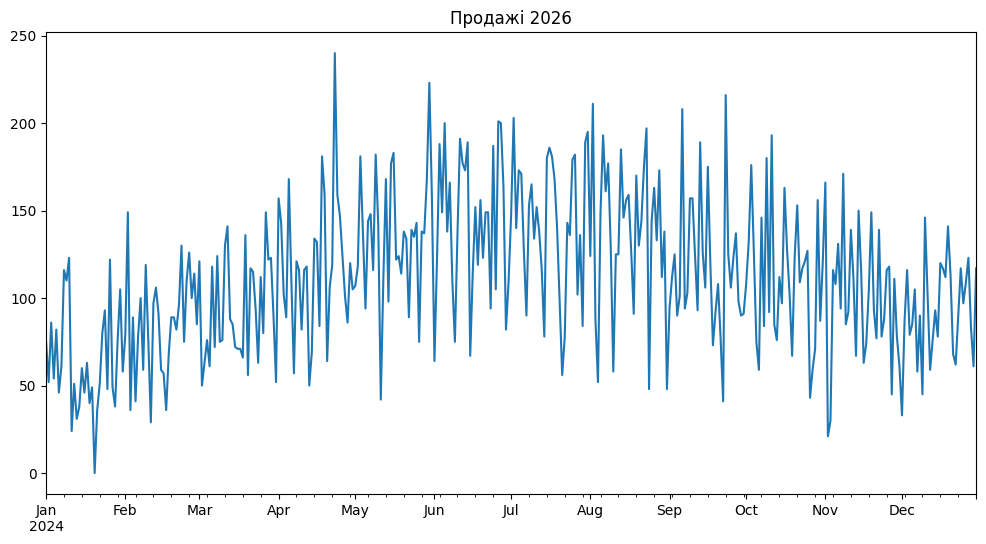

In [11]:
sales_data["sales"].plot(figsize=(12, 6), title="Продажі 2026")
plt.show()

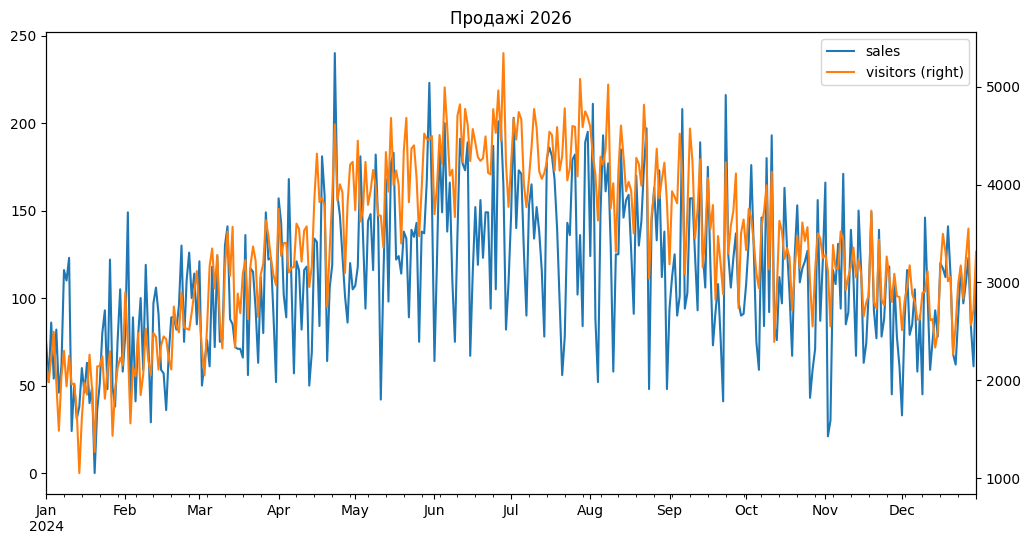

In [17]:
sales_data[["sales", "visitors"]].plot(
    figsize=(12,6),
    secondary_y="visitors",
    title="Продажі 2026"
)
plt.show()

In [22]:
monthly_sales = sales_data["sales"].resample("ME").sum()

In [23]:
monthly_sales

,sales
2024-01-31,1963
2024-02-29,2465
2024-03-31,2869
2024-04-30,3559
2024-05-31,4185
2024-06-30,4250
2024-07-31,4420
2024-08-31,4231
2024-09-30,3550
2024-10-31,3490


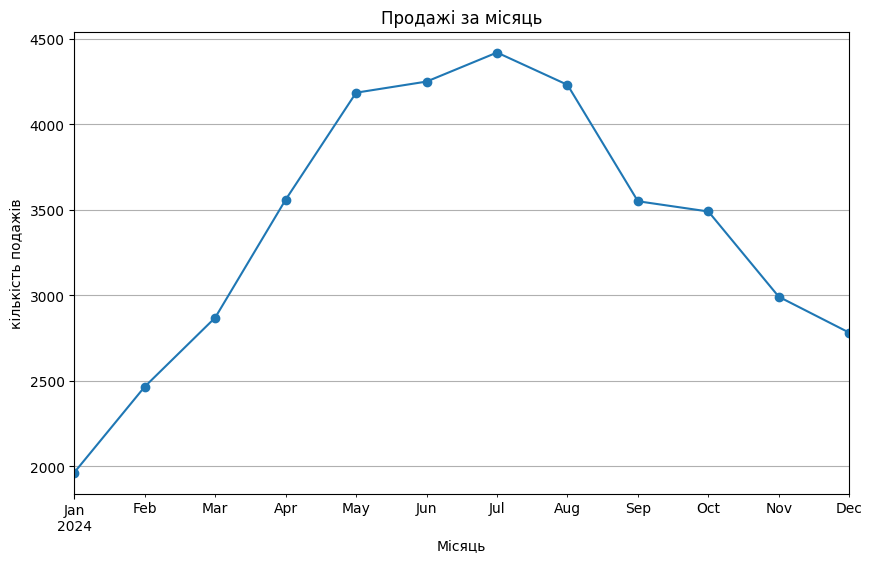

In [29]:
monthly_sales.plot(
    kind="line",
    marker="o",
    figsize=(10,6),
    title="Продажі за місяць",
    xlabel="Місяць",
    ylabel="кількість подажів",
    grid=True
 );

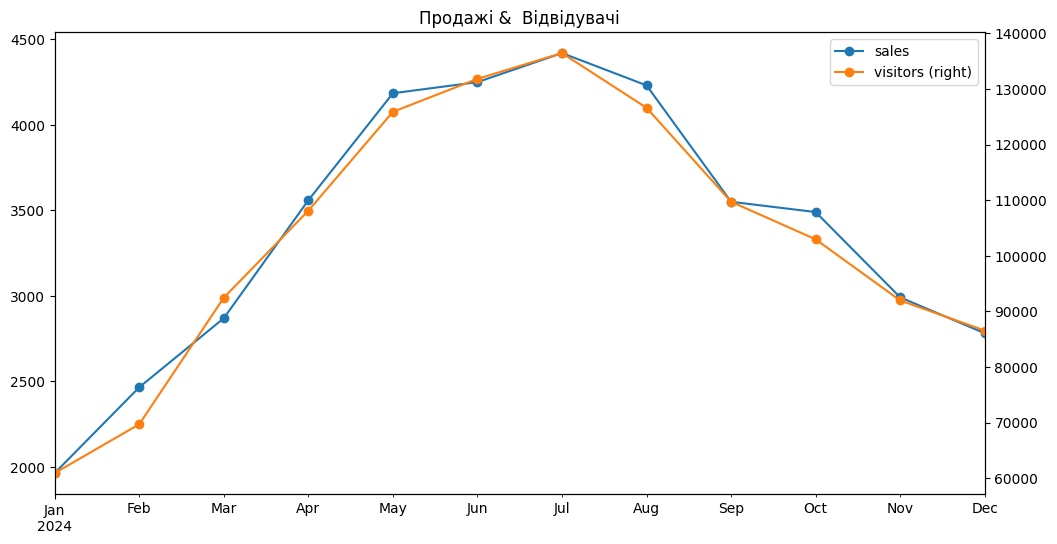

In [31]:
monthly_data = sales_data[["sales","visitors"]].resample("ME").sum()
monthly_data.plot(
    figsize=(12,6),
    marker="o",
    secondary_y="visitors",
    title="Продажі &  Відвідувачі"
);

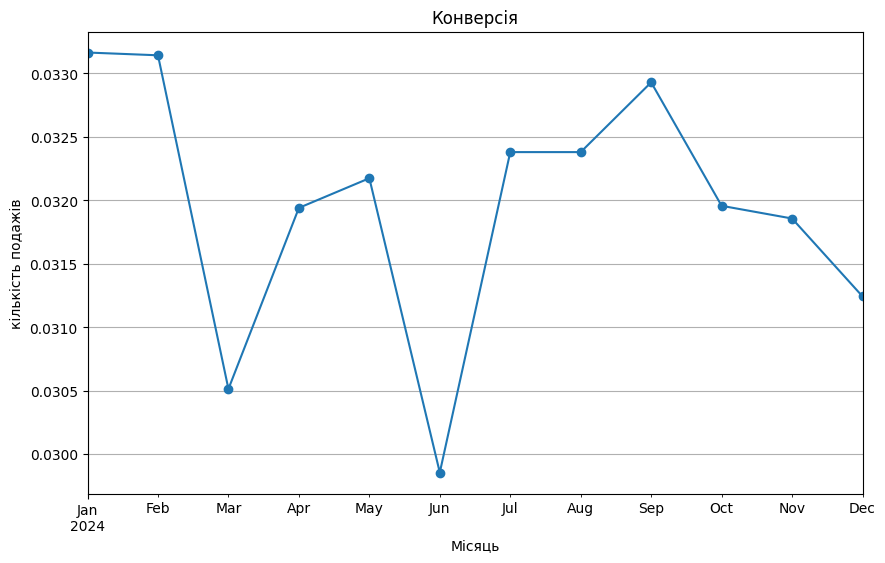

In [38]:
sales_data["conversion"].resample("ME").mean().plot(
    kind="line",
    marker="o",
    figsize=(10,6),
    title="Конверсія",
    xlabel="Місяць",
    ylabel="кількість подажів",
    grid=True
    );

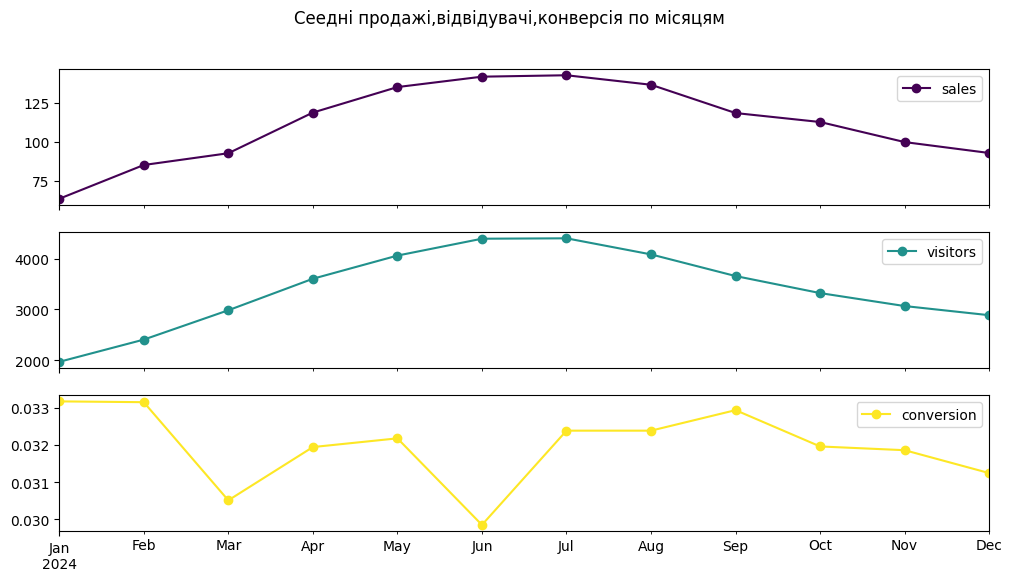

In [39]:
monthly_data = sales_data[["sales","visitors","conversion"]].resample("ME").mean()
monthly_data.plot(
    figsize=(12,6),
    marker="o",
    subplots=True,
    colormap="viridis",
    title="Сеедні продажі,відвідувачі,конверсія по місяцям"
);

<function matplotlib.pyplot.show(close=None, block=None)>

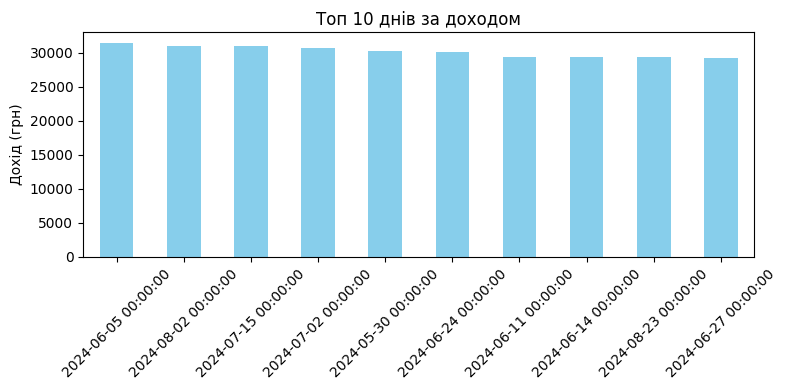

In [40]:
top_days = sales_data.nlargest(10,"income")["income"]
top_days.plot.bar(
    figsize=(8,4),
    color="skyblue",
    title="Топ 10 днів за доходом",
    ylabel="Дохід (грн)",
)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show


In [41]:
top_days.index

DatetimeIndex(['2024-06-05', '2024-08-02', '2024-07-15', '2024-07-02',
               '2024-05-30', '2024-06-24', '2024-06-11', '2024-06-14',
               '2024-08-23', '2024-06-27'],
              dtype='datetime64[ns]', freq=None)

In [42]:
[date.strftime("%d %b %Y") for date in top_days.index]

['05 Jun 2024',
 '02 Aug 2024',
 '15 Jul 2024',
 '02 Jul 2024',
 '30 May 2024',
 '24 Jun 2024',
 '11 Jun 2024',
 '14 Jun 2024',
 '23 Aug 2024',
 '27 Jun 2024']

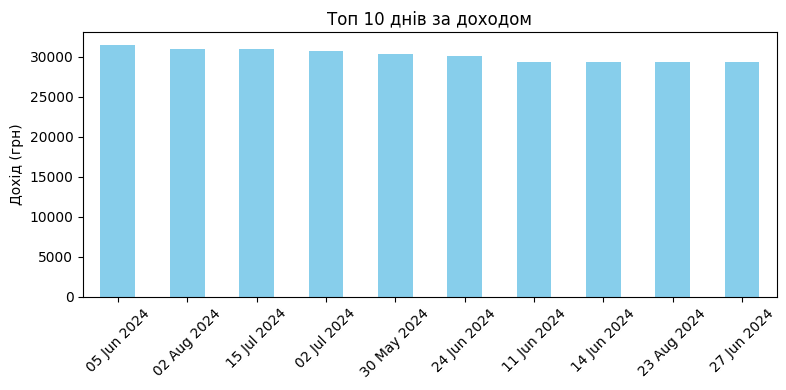

In [43]:
ax = top_days.plot.bar(
    figsize=(8,4),
    color="skyblue",
    title="Топ 10 днів за доходом",
    ylabel="Дохід (грн)",
)
labels = [date.strftime("%d %b %Y") for date in top_days.index]
ax.set_xticklabels(labels)
plt.xticks(rotation=45)
plt.tight_layout()

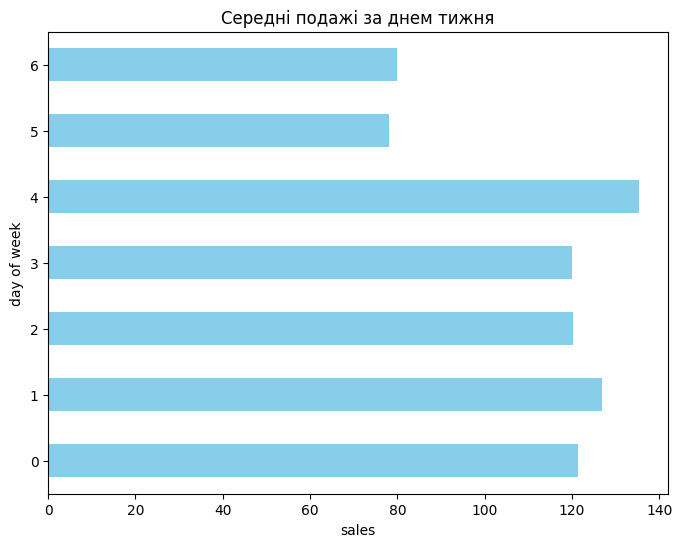

In [44]:
sales_data.groupby(sales_data.index.weekday)["sales"].mean().plot.barh(
    figsize=(8,6),
    color="skyblue",
    title="Середні подажі за днем тижня",
    xlabel="sales",
   ylabel="day of week",
);

In [45]:
avg_sales_by_day = sales_data.groupby(sales_data.index.weekday)["sales"].mean()

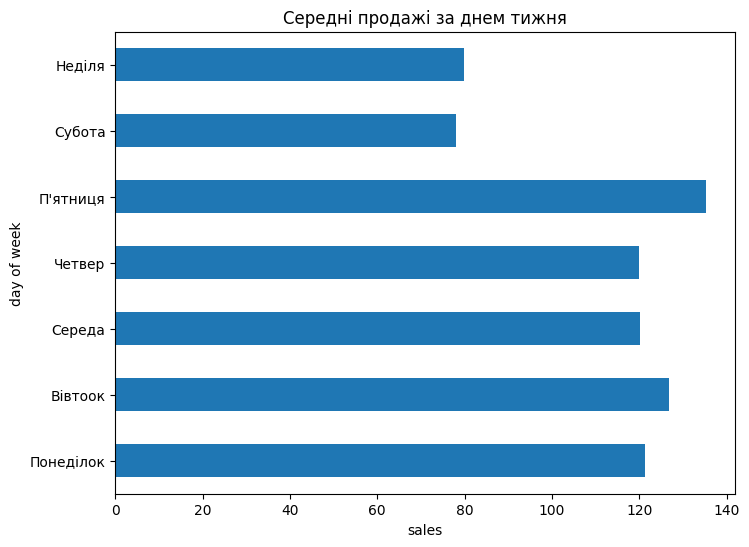

In [50]:
 ax = avg_sales_by_day.plot.barh(
    figsize=(8,6),
    #color=blue",
    title="Середні продажі за днем тижня",
    xlabel="sales",
    ylabel="day of week",
)
ax.set_yticklabels(["Понеділок","Вівтоок","Середа","Четвер","П'ятниця","Субота","Неділя"]);